# Exam

> Data: **2024-09-10**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il dataset (preso da [Kaggle](https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers)) contiene dati relativi ai clienti di una banca. La variabile da predire è `Exited` e indica se il cliente ha abbandonato la banca.

Note: Il file csv che si trova al [link](https://bit.ly/3ATiuxi).

### Imports

In [ ]:
# !curl -sLo dataset.zip "https://link"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
FILE_ID = "15wIkq3jb56c7UKqyC8u-TL5GoC0IExTy"
!curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


#### Instances

In [ ]:
df.shape

(10000, 14)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


<Axes: >

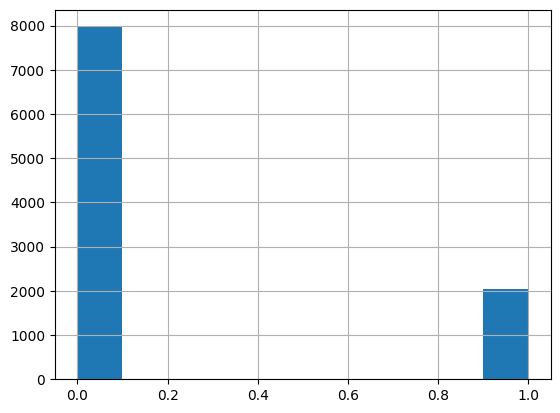

In [ ]:
df["Exited"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire?

In [ ]:
df.shape[0]

10000

> Il dataset contiene 10000 istanze.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

> Si, il dataset è completo in quanto non sono presenti missing values.

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


> No, il dataset non è bilanciato, in quanto abbiamo 7963 istanze di `No` e 2037 istanze di `Yes` per l'attributo `Exited`.

---

### Domanda 02 (Punti 4)

Dopo aver discretizzato l’attributo `Age` in 5 gruppi, verificare se è vero che i clienti più anziani hanno meno probabilità di abbandonare la banca rispetto ai più giovani. Considerando i clienti con più di 60 anni, verificare se è vero che maggiore è il saldo (`Balance`) e minore è la probabilità che il cliente abbandoni la banca.

#### Dopo aver discretizzato l’attributo `Age` in 5 gruppi, verificare se è vero che i clienti più anziani hanno meno probabilità di abbandonare la banca rispetto ai più giovani. (Punti 2)

In [ ]:
age_bins = pd.cut(df["Age"], bins=5)
probability = df.groupby(age_bins, observed=False)["Exited"].mean()
probability

,Exited
Age,
"(17.926, 32.8]",0.076344
"(32.8, 47.6]",0.188182
"(47.6, 62.4]",0.529978
"(62.4, 77.2]",0.214925
"(77.2, 92.0]",0.041667


<Axes: xlabel='Age'>

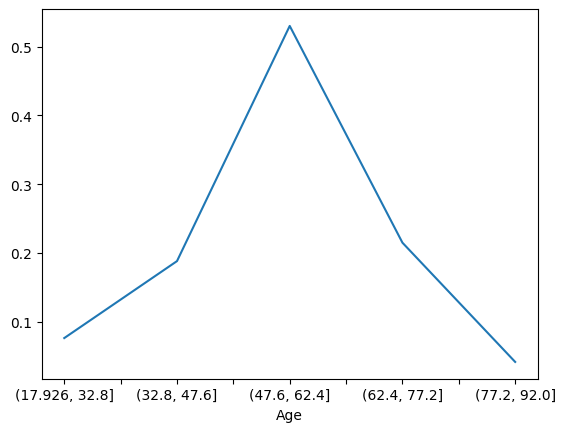

In [ ]:
probability.plot()

> Se consideriamo solo ed esclusivamente la fascia più anziana, ovvero `(77.2, 92.0]`, allora sì, hanno meno probabilità di abbandonare in senso assoluto.
>
> Valutando meglio le probabilità, però, possiamo notare come le due fasce più estreme sono quelle che hanno meno probabilità di abbandonare, seguite dalle due fasce intermedie, le quali hanno una probabilità di abbandono leggermente più alte rispetto le precedenti, mentre la fascia con la probabilità decisamente più alta di abbandono è la fascia intermedia, quella `(47.6, 62.4]`.

#### Considerando i clienti con più di 60 anni, verificare se è vero che maggiore è il saldo (`Balance`) e minore è la probabilità che il cliente abbandoni la banca. (Punti 2)

In [ ]:
over_60 = df[df["Age"] > 60]
balance_bin = pd.cut(over_60["Balance"], bins=5)
probability = over_60.groupby(balance_bin, observed=False)["Exited"].mean()
probability

,Exited
Balance,
"(-187.013, 37402.626]",0.142012
"(37402.626, 74805.252]",0.400000
"(74805.252, 112207.878]",0.279070
"(112207.878, 149610.504]",0.349315
"(149610.504, 187013.13]",0.157895


<Axes: xlabel='Balance'>

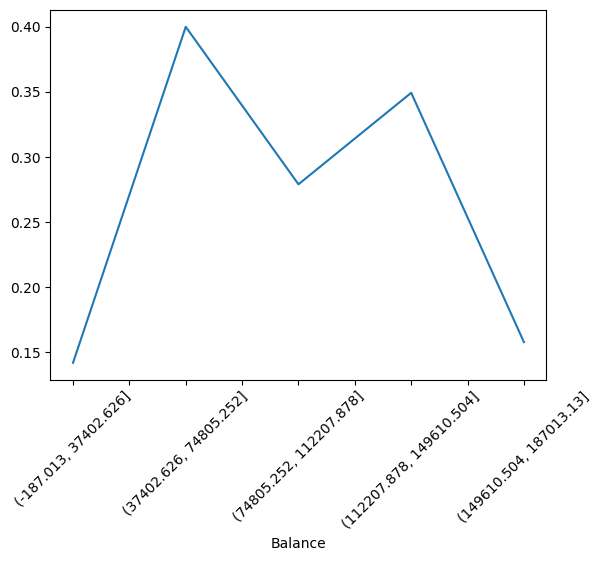

In [ ]:
probability.plot(rot=45)

> Anche in questo caso, se consideriamo il range più alto di `Balance`, ovvero `(149610.504, 187013.13]`, allora sì, questi clienti over 60 hanno la più bassa probabilità di abbandono.
>
> Ma come nel caso precedente, non c'è una correlazione lineare tra saldo e tasso di abbandono. Quindi non sarebbe proprio corretto dire che più il saldo di un cliente è alto, allora sicuramente il tasso di abbandono sarà più basso.

---

### Domanda 03 (Punti 3)

Riportare in una pivot table la media di `CreditScore` raggruppando per uomini e donne (sulle righe) e i valori di salario stimato discretizzati in 5 gruppi (sulle colonne). Si può dire che i clienti con `CreditScore` più elevato sono quelli con il salario più alto? Si notano differenze tra uomini e donne?

In [ ]:
estimated_salary = pd.cut(df["EstimatedSalary"], bins=5, labels=["Basso", "Medio basso", "Medio", "Medio alto", "Alto"])
pd.pivot_table(df, index="Gender", columns=estimated_salary, values="CreditScore", aggfunc="mean", observed=False)

EstimatedSalary,Basso,Medio basso,Medio,Medio alto,Alto
Gender,,,,,
Female,657.436219,651.474747,646.934899,646.401064,652.440357
Male,649.769731,650.378284,649.466117,649.247855,652.460346


> No, non è vero che i clienti con salario stimato più alto abbiano un `CreditScore` più alto. I `CreditScore` sono all'incirca sui 650 per tutte le fasce di salario stimato e genere. Gli unici valori leggermente più distanti da questo valore sono le donne con salario stimato basso, le quali hanno `CreditScore` di 657 e per le donne nella fascia media e media alta, con un `CreditScore` di 646.

---

### Domanda 04 (Punti 2)

Considerando soltanto i clienti che hanno una carta di credito e più di 100000 euro di credito, confrontare in un istogramma la distribuzione del `CreditScore` dei clienti francesi e di quelli spagnoli. Chi ha `CreditScore` maggiore?

In [ ]:
mask_card = df["HasCrCard"] == 1
mask_balance = df["Balance"] > 100000
clients = df[mask_card & mask_balance]
clients

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9982,9983,15768163,Griffin,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
9985,9986,15586914,Nepean,659,France,Male,36,6,123841.49,2,1,0,96833.00,0
9987,9988,15588839,Mancini,606,Spain,Male,30,8,180307.73,2,1,1,1914.41,0
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0


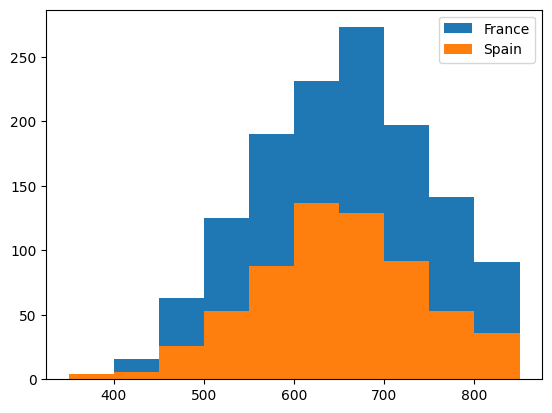

In [ ]:
mask_france = clients["Geography"] == "France"
mask_spain = clients["Geography"] == "Spain"
plt.hist(clients[mask_france]["CreditScore"], label="France")
plt.hist(clients[mask_spain]["CreditScore"], label="Spain")
plt.legend()
plt.show()

> Il `CreditScore` medio maggiore lo hanno i clienti francesi, in quanto l'istogramma dei francesi risulta più alto di quello degli spagnoli.

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire l’abbandono dei clienti della banca. Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare le eventuali istanze che contengono valori nulli, trasformare opportunamente valori categorici e dividere il dataset in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "train" e 1/4 nel dataset "test" preservando le proporzioni delle classi nella colonna target.

Allenare il train con il modello DecisionTree e valutare l’accuratezza ottenuta sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello KNeighborsClassifier. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione i valori di accuracy, F1 score, l’analisi della confusion matrix e la predizione effettuata da un dummy classifier a scelta.

In [ ]:
df = pd.read_csv("dataset.csv")
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df.dropna(inplace=True)
df["Gender"] = df["Gender"].map({ "Female": 0, "Male": 1 })
df = pd.get_dummies(df, columns=["Geography"], dtype=int)
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [ ]:
X, y = df.drop("Exited", axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree:
TRAIN
    Accuracy: 1.0
    F1: 1.0
[[5972    0]
 [   0 1528]]
------------------------------
TEST
    Accuracy: 0.8016
    F1: 0.5212355212355212
[[1734  257]
 [ 239  270]]

KNeighbors:
TRAIN
    Accuracy: 0.8149333333333333
    F1: 0.3182711198428291
[[5788  184]
 [1204  324]]
------------------------------
TEST
    Accuracy: 0.7652
    F1: 0.14055636896046853
[[1865  126]
 [ 461   48]]

Dummy:
TRAIN
    Accuracy: 0.7962666666666667
    F1: 0.0
[[5972    0]
 [1528    0]]
------------------------------
TEST
    Accuracy: 0.7964
    F1: 0.0
[[1991    0]
 [ 509    0]]



> Analizzando le accuracy dei modelli possiamo notare come si aggirino tutte attorno all'80%, sia per il dataset di train che di test, con le eccezzioni del `DecisionTree` sul train che arriva al 100% e il `KNeighbors` sul test che arriva al 76%.
>
> Analizzando invece la metrica di F1, possiamo notare come queste siano tutte decisamente più basse. Per il modello `KNeighbors` possiamo notare come sul train abbia un F1 di 32% mentre sul test addirittura del 14%. Il motivo di questi valori così bassi è da attribuire principalmente alla classe 1. Infatti, dalla confusion matrix possiamo vedere come la maggior parte degli errori riguarda all'errata predizione della classe 1, il modello predice che i clienti non abbandonano la banca quando in realtà i clienti la avrebbero abbandonata.
>
> Il modello `Dummy` sarebbe un discorso a parte, in quanto questo modello effettua predizioni a priori in base a una determinata strategia. In questo caso il modello predice sempre la classe più frequente, motivo per cui abbia una accuracy di quasi 80% sia su train che su test. Questo lo si può anche comprendere dalla metrica F1 e dalla confusion matrix.

---

### Domanda 02 (Punti 1)

Confrontare l’accuratezza ottenuta nel punto precedente con l’accuratezza che si ottiene con una 10 Fold cross validation.

In [ ]:
for name, model in models.items():
    scores_accuracy = cross_val_score(model, X, y, cv=10)
    scores_f1 = cross_val_score(model, X, y, cv=10, scoring="f1")
    print(f"{name}:")
    print("=" * 30)
    print("ACCURACY")
    print("    Score:", scores_accuracy.mean())
    print("    Scores:", scores_accuracy)
    print("-" * 30)
    print("F1")
    print("    Score:", scores_f1.mean())
    print("    Scores:", scores_f1)
    print("=" * 30)
    print()

DecisionTree:
ACCURACY
    Score: 0.7937000000000001
    Scores: [0.794 0.782 0.82  0.788 0.811 0.766 0.801 0.796 0.793 0.786]
------------------------------
F1
    Score: 0.5017137339070401
    Scores: [0.49509804 0.43229167 0.57345972 0.49038462 0.55737705 0.4375
 0.52505967 0.51196172 0.50596659 0.48803828]

KNeighbors:
ACCURACY
    Score: 0.7664000000000001
    Scores: [0.765 0.776 0.75  0.77  0.769 0.766 0.766 0.759 0.782 0.761]
------------------------------
F1
    Score: 0.13613252011738838
    Scores: [0.13284133 0.17647059 0.0942029  0.15441176 0.14126394 0.13970588
 0.11363636 0.11070111 0.18656716 0.11152416]

Dummy:
ACCURACY
    Score: 0.7962999999999999
    Scores: [0.796 0.796 0.796 0.796 0.796 0.796 0.796 0.797 0.797 0.797]
------------------------------
F1
    Score: 0.0
    Scores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]



> I risultati ottenuti dalla 10 fold cross validation sono risultati in linea con quanto abbiamo visto al punto precedente, non c'è un significativo miglioramento o peggioramento rispetto a quanto visto precedentemente.

---

### Domanda 03 (Punti 5)

Considerando i dati del test set e utilizzando il modello DecisionTree, la probabilità di predire l’abbandono del cliente della banca è la stessa per uomini e donne? Valutare se l’accuratezza della predizione negli uomini è la stessa ottenuta nelle donne. Come varia l’accuratezza se elimino l’attributo `Gender`?

#### Considerando i dati del test set e utilizzando il modello DecisionTree, la probabilità di predire l’abbandono del cliente della banca è la stessa per uomini e donne? (Punti 2)

In [ ]:
decision_tree = models["DecisionTree"]
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

In [ ]:
mask_female = X_test["Gender"] == 0
mask_male = X_test["Gender"] == 1
mask_churn = y_test == 1

probability_churn_female = y_pred[mask_female & mask_churn].shape[0] / y_pred[mask_female].shape[0]
probability_churn_male = y_pred[mask_male & mask_churn].shape[0] / y_pred[mask_male].shape[0]

print("Female:")
print("    Shape:", y_pred[mask_female].shape)
print("    Probability of churn:", probability_churn_female)
print("Male:")
print("    Shape:", y_pred[mask_male].shape)
print("    Probability of churn:", probability_churn_male)

Female:
    Shape: (1130,)
    Probability of churn: 0.24424778761061947
Male:
    Shape: (1370,)
    Probability of churn: 0.17007299270072992


> Dai valori ottenuti risulta leggermente più probabile che l'abbandono della banca sia un cliente femmina che maschio, con le rispettive probabilità 24% e 17%.

#### Valutare se l’accuratezza della predizione negli uomini è la stessa ottenuta nelle donne. (Punti 2)

In [ ]:
print("Female:")
print("    Shape:", y_pred[mask_female].shape)
print("    Accuracy:", accuracy_score(y_test[mask_female], y_pred[mask_female]))
print("Male:")
print("    Shape:", y_pred[mask_male].shape)
print("    Accuracy:", accuracy_score(y_test[mask_male], y_pred[mask_male]))

Female:
    Shape: (1130,)
    Accuracy: 0.7823008849557522
Male:
    Shape: (1370,)
    Accuracy: 0.8175182481751825


> Dai valori ottenuti risulta che il cliente maschio abbia una accuratezza leggermente migliore riguardo l'abbandono rispetto al cliente femmina, con i rispettivi valori di 82% e 78%.

#### Come varia l’accuratezza se elimino l’attributo `Gender`? (Punti 1)

In [ ]:
X, y = df.drop(["Exited", "Gender"], axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
decision_tree = models["DecisionTree"]
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7952
F1: 0.5123809523809524
[[1719  272]
 [ 240  269]]


In [ ]:
print("Female:")
print("    Shape:", y_pred[mask_female].shape)
print("    Accuracy:", accuracy_score(y_test[mask_female], y_pred[mask_female]))
print("Male:")
print("    Shape:", y_pred[mask_male].shape)
print("    Accuracy:", accuracy_score(y_test[mask_male], y_pred[mask_male]))

Female:
    Shape: (1130,)
    Accuracy: 0.7946902654867256
Male:
    Shape: (1370,)
    Accuracy: 0.7956204379562044


> Rimovendo l'attributo `Gender` dal dataset possiamo notare come il modello `DecisionTree` abbia pressoché le stesse metriche di accuratezza e F1, però l'accuratezza sulla predizione tra gli uomini e le donne sembra essere più equilibrata rispetto al precedente caso.

---

### Domanda 04 (Punti 2)

A partire dal dataset iniziale (in cui sono stati eliminati eventuali attributi inutili ed eventuali istanze con valori nulli) aggiungere una nuova feature nel dataset con il valore di `(EstimatedSalary * Tenure + Balance) / 2`. L’accuratezza del modello DecisionTree migliora? Come cambia l’accuratezza se i valori della nuova feature vengono discretizzati in 10 gruppi?

In [ ]:
df = pd.read_csv("dataset.csv")
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df.dropna(inplace=True)
df["Gender"] = df["Gender"].map({ "Female": 0, "Male": 1 })
df = pd.get_dummies(df, columns=["Geography"], dtype=int)

In [ ]:
df["new_feature"] = (df["EstimatedSalary"] * df["Tenure"] + df["Balance"]) / 2
df[["EstimatedSalary", "Tenure", "Balance", "new_feature"]]

,EstimatedSalary,Tenure,Balance,new_feature
0,101348.88,2,0.00,101348.880
1,112542.58,1,83807.86,98175.220
2,113931.57,8,159660.80,535556.680
3,93826.63,1,0.00,46913.315
4,79084.10,2,125510.82,141839.510
...,...,...,...,...
9995,96270.64,5,0.00,240676.600
9996,101699.77,10,57369.61,537183.655
9997,42085.58,7,0.00,147299.530
9998,92888.52,3,75075.31,176870.435


In [ ]:
X, y = df.drop(["Exited"], axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
decision_tree = models["DecisionTree"]
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

print("=" * 30)
print("    Accuracy:", accuracy_score(y_test, y_pred))
print("    F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("=" * 30)
print()

    Accuracy: 0.7956
    F1: 0.4985279685966634
[[1735  256]
 [ 255  254]]



> Le performance in presenza della nuova feature `new_feature` rimangono pressoché simili, con un lieve peggioramento della metrica F1.

In [ ]:
new_feature_bins = pd.cut(df["new_feature"].tolist(), 10).codes
new_feature_bins

array([0, 0, 5, ..., 1, 1, 1], dtype=int8)

In [ ]:
df["new_feature_bins"] = new_feature_bins
df[["new_feature", "new_feature_bins"]]

,new_feature,new_feature_bins
0,101348.880,0
1,98175.220,0
2,535556.680,5
3,46913.315,0
4,141839.510,1
...,...,...
9995,240676.600,2
9996,537183.655,5
9997,147299.530,1
9998,176870.435,1


In [ ]:
X, y = df.drop(["Exited", "new_feature"], axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
decision_tree = models["DecisionTree"]
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

print("=" * 30)
print("    Accuracy:", accuracy_score(y_test, y_pred))
print("    F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("=" * 30)
print()

    Accuracy: 0.79
    F1: 0.48579823702252695
[[1727  264]
 [ 261  248]]



> Anche in questo caso come il precedente, performance molto simili rispetto al singolo attributo `new_feature` e in assenza di esso.

---

### Domanda 05 (Punti 2)

A partire dal dataset iniziale (in cui sono stati eliminati eventuali attributi inutili ed eventuali istanze con valori nulli) trovare i valori migliori dei parametri `criterion` e `max_depth` del classificatore DecisionTree. Come varia l’accuracy?

In [ ]:
df = pd.read_csv("dataset.csv")
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df.dropna(inplace=True)
df["Gender"] = df["Gender"].map({ "Female": 0, "Male": 1 })
df = pd.get_dummies(df, columns=["Geography"], dtype=int)

In [ ]:
X, y = df.drop(["Exited"], axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
decision_tree = models["DecisionTree"]

params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 4, 6, 8, 10],
}
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("=" * 30)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'criterion': 'entropy', 'max_depth': 6}
Best score: 0.86
Accuracy: 0.8496
F1: 0.5414634146341464
[[1902   89]
 [ 287  222]]


> I parametri ottimali ottenuti per `criterion` e `max_depth` sono rispettivamente `entropy` e `6`.
>
> Le metriche di accuratezza e F1 sembrano migliorare di qualche punto percentuale, toccando l'85% di accuracy e 54% di F1.

---

### Domanda 06 (Punti 03)

Creare una pipeline in cui gli attributi `Balance` e `EstimatedSalary` sono discretizzati in 6 intervalli, l’attributo `Tenure` è scalato nell’intervallo 0-1 e tutti gli altri attributi sono lasciati invariati. La pipeline deve applicare il modello DecisionTree con i parametri migliori trovati al punto 5. Valutare l’accuratezza della classificazione.

In [ ]:
discretizer = KBinsDiscretizer(n_bins=6, strategy="uniform")
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["Balance", "EstimatedSalary"]),
        ("scaler", scaler, ["Tenure"]),
    ],
    remainder="passthrough",
    force_int_remainder_cols=False,
)
column_transformer

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('discretizer',
                                 KBinsDiscretizer(n_bins=6, strategy='uniform'),
                                 ['Balance', 'EstimatedSalary']),
                                ('scaler', StandardScaler(), ['Tenure'])])

In [ ]:
best_criterion = grid_search.best_params_["criterion"]
best_max_depth = grid_search.best_params_["max_depth"]
decision_tree = DecisionTreeClassifier(criterion=best_criterion, max_depth=best_max_depth, random_state=0)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=6,
                                                                   strategy='uniform'),
                                                  ['Balance',
                                                   'EstimatedSalary']),
                                                 ('scaler', StandardScaler(),
                                                  ['Tenure'])])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=6,
                                        random_state=0))])

In [ ]:
X, y = df.drop(["Exited"], axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8492
F1: 0.5474189675870348
[[1895   96]
 [ 281  228]]


> Le performance della pipeline sono simili a quelle ottenute nel punto precedente, quindi sono leggermente migliori rispetto alle altre, come già detto nel punto precedente.

---

### Domanda 07 (Punti 3)

Creare una nuova pipeline che seleziona N componenti tra quelle ottenute dalla pipeline del punto 6 utilizzando la funzione TruncatedSVD e applica il modello DecisionTree. Attraverso la funzione di gridSearchCV, valutare il valore migliore per il numero di componenti (`n_components`) tra 2, 4 e 6 e il numero migliore di gruppi in cui discretizzare gli attributi `Balance` e `EstimatedSalary`.

In [ ]:
X, y = df.drop(["Exited"], axis=1), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [ ]:
svd = TruncatedSVD(random_state=0)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("svd", svd),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=6,
                                                                   strategy='uniform'),
                                                  ['Balance',
                                                   'EstimatedSalary']),
                                                 ('scaler', StandardScaler(),
                                                  ['Tenure'])])),
                ('svd', TruncatedSVD(random_state=0)),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=6,
                                        random_state=0))])

In [ ]:
params = {
    "column_transformer__discretizer__n_bins": [4, 6, 8, 10],
    "svd__n_components": [2, 4, 6],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("=" * 30)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'column_transformer__discretizer__n_bins': 8, 'svd__n_components': 6}
Best score: 0.8316000000000001
Accuracy: 0.8288
F1: 0.38328530259365995
[[1939   52]
 [ 376  133]]


> I parametri ottimali per `n_bins` e `n_components` sono rispettivamente `8` e `6`.
>
> L'accuratezza della pipeline risulterebbe essere simile alle precedenti, ma l'F1 cala un pochino.